# Rigol MSO5000 Binary Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import io

import numpy as np
import matplotlib.pyplot as plt
import requests
from RigolWFM import Wfm

repo = 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/'

def sample_url(relative_path: str) -> str:
    return repo + relative_path

def _time_scale(times):
    span = float(abs(times[-1] - times[0])) if len(times) > 1 else 1.0
    if span >= 1e-3:
        return 1e3, 'ms'
    if span >= 1e-6:
        return 1e6, 'us'
    if span >= 1e-9:
        return 1e9, 'ns'
    return 1e12, 'ps'

def _volt_scale(values):
    peak = max(float(np.max(np.abs(v))) for v in values) if values else 1.0
    if peak >= 1.0:
        return 1.0, 'V'
    if peak >= 1e-3:
        return 1e3, 'mV'
    if peak >= 1e-6:
        return 1e6, 'uV'
    return 1e9, 'nV'

def plot_analog_channels(w, title=None, max_points=5000):
    active = [ch for ch in w.channels if ch.times is not None and ch.volts is not None]
    if not active:
        print('No analog channels are enabled in this capture.')
        return

    colors = ['green', 'red', 'blue', 'orange']
    t_scale, t_unit = _time_scale(active[0].times)
    v_scale, v_unit = _volt_scale([ch.volts for ch in active])

    fig, axes = plt.subplots(len(active), 1, sharex=True, figsize=(10, 2.5 * len(active)))
    if len(active) == 1:
        axes = [axes]

    for ax, ch, color in zip(axes, active, colors):
        stride = max(len(ch.times) // max_points, 1)
        ax.plot(ch.times[::stride] * t_scale, ch.volts[::stride] * v_scale, color=color)
        ax.set_ylabel(v_unit)
        ax.set_title(f'CH{ch.channel_number}  {ch.points} points')
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_logic_window(w, names=None, start=0, stop=4000, title=None):
    if not w.logic_channels:
        print('No logic channels are enabled in this capture.')
        return

    if names is None:
        names = list(w.logic_channels)

    if w.logic_times is None:
        times = np.arange(len(next(iter(w.logic_channels.values()))), dtype=np.float64)
    else:
        times = w.logic_times

    stop = min(stop, len(times))
    t_scale, t_unit = _time_scale(times[start:stop])

    fig, axes = plt.subplots(len(names), 1, sharex=True, figsize=(10, 1.6 * len(names)))
    if len(names) == 1:
        axes = [axes]

    colors = ['green', 'red', 'blue', 'orange', 'purple', 'brown']
    for ax, name, color in zip(axes, names, colors):
        trace = w.logic_channels[name]
        ax.step(times[start:stop] * t_scale, trace[start:stop], where='post', color=color)
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_ylabel(name)
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

from RigolWFM import DS5000_scopes, MSO5074_scopes


A few accepted model aliases for this family are:

In [2]:
print('MSO5000 family aliases:')
print(DS5000_scopes)

print()
print('MSO5074 aliases:')
print(MSO5074_scopes)

MSO5000 family aliases:
['5', '5000', 'MSO5000']

MSO5074 aliases:
['5074', 'MSO5074']


## MSO5000-A - Four-channel analog capture

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/MSO5000-A.png" width="60%">

In [3]:
filename = 'bin/MSO5000-A.bin'
w = Wfm.from_url(sample_url(filename), '5')
print(w.describe())

    General:
        File Model   = MSO5XXX
        User Model   = 5
        Parser Model = bin5000
        Firmware     = 01
        Filename     = MSO5000-A.bin
        Channels     = [1, 2, 3, 4]

    Trigger:
        Derived Level (CH1) = 2.48  V
        Derived Level (CH2) = -439.47 mV
        Derived Level (CH3) = 319.48 mV
        Derived Level (CH4) = 2.37  V

     Channel 1:
         Coupling =  unknown
            Scale =   406.90 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  500.000 µs/div
           Offset =    0.000  s
            Delta =    5.000 µs/point
           Points =     1000

         Count    = [        1,        2,        3  ...       999,     1000]
           Raw    = [      200,      242,      254  ...        18,       12]
           Times  = [-2.500 ms,-2.495 ms,-2.490 ms  ...  2.490 ms, 2.495 ms]
           Volts  = [697.55 mV,155.01 mV,  0.00  V  ...   3.02  V,  3.10  V]

     Channel

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/MSO5000-A.bin'


### Plot all enabled analog channels

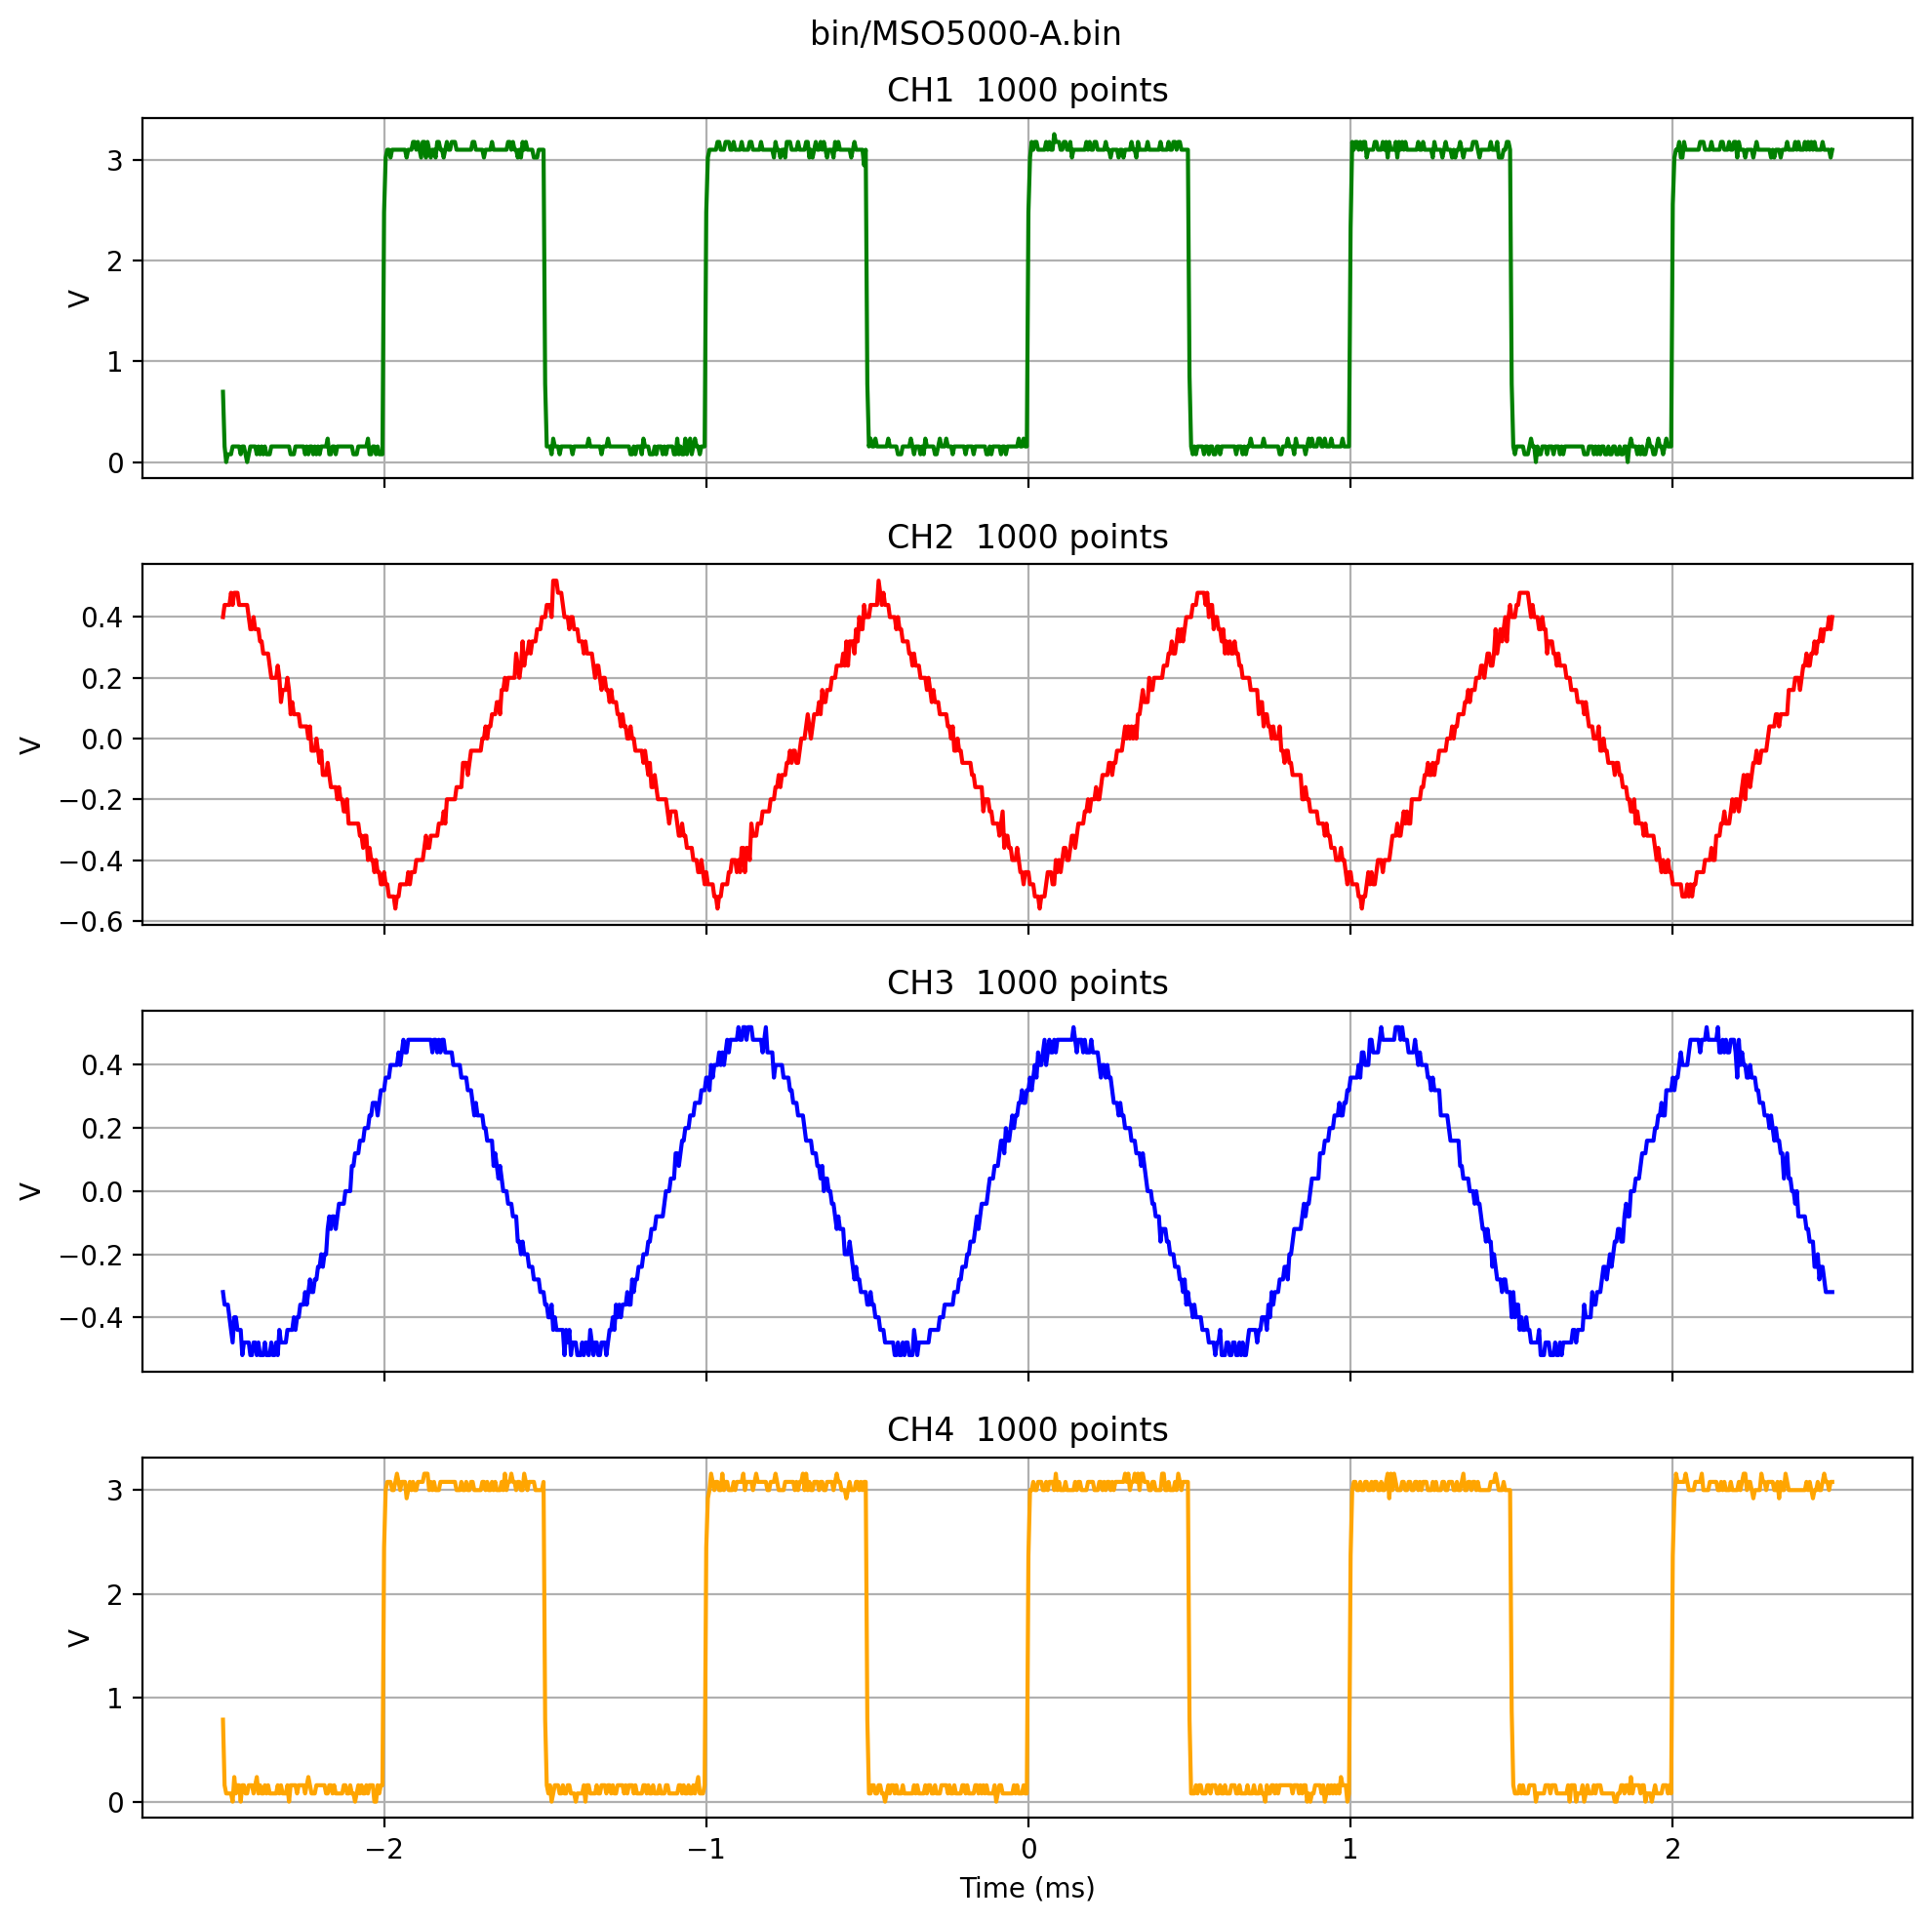

In [4]:
plot_analog_channels(w, title=filename)

## MSO5000-B - Longer analog capture

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/MSO5000-B.png" width="60%">

In [5]:
filename = 'bin/MSO5000-B.bin'
w = Wfm.from_url(sample_url(filename), '5')
print(w.describe())

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/MSO5000-B.bin'


    General:
        File Model   = MSO50XX
        User Model   = 5
        Parser Model = bin5000
        Firmware     = 01
        Filename     = MSO5000-B.bin
        Channels     = [1, 2, 3, 4]

    Trigger:
        Derived Level (CH1) = 1.55  V
        Derived Level (CH2) = 439.47 mV
        Derived Level (CH3) = 479.22 mV
        Derived Level (CH4) = 1.58  V

     Channel 1:
         Coupling =  unknown
            Scale =   426.28 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =   10.000 ms/div
           Offset =    0.000  s
            Delta =  100.000 ns/point
           Points =  1000000

         Count    = [        1,        2,        3  ...    999999,  1000000]
           Raw    = [      121,      110,      104  ...       156,      150]
           Times  = [-50.000 ms,-50.000 ms,-50.000 ms  ... 50.000 ms,50.000 ms]
           Volts  = [  1.71  V,  1.86  V,  1.94  V  ...   1.24  V,  1.32  V]

     Chann

### Plot a decimated view of the long capture

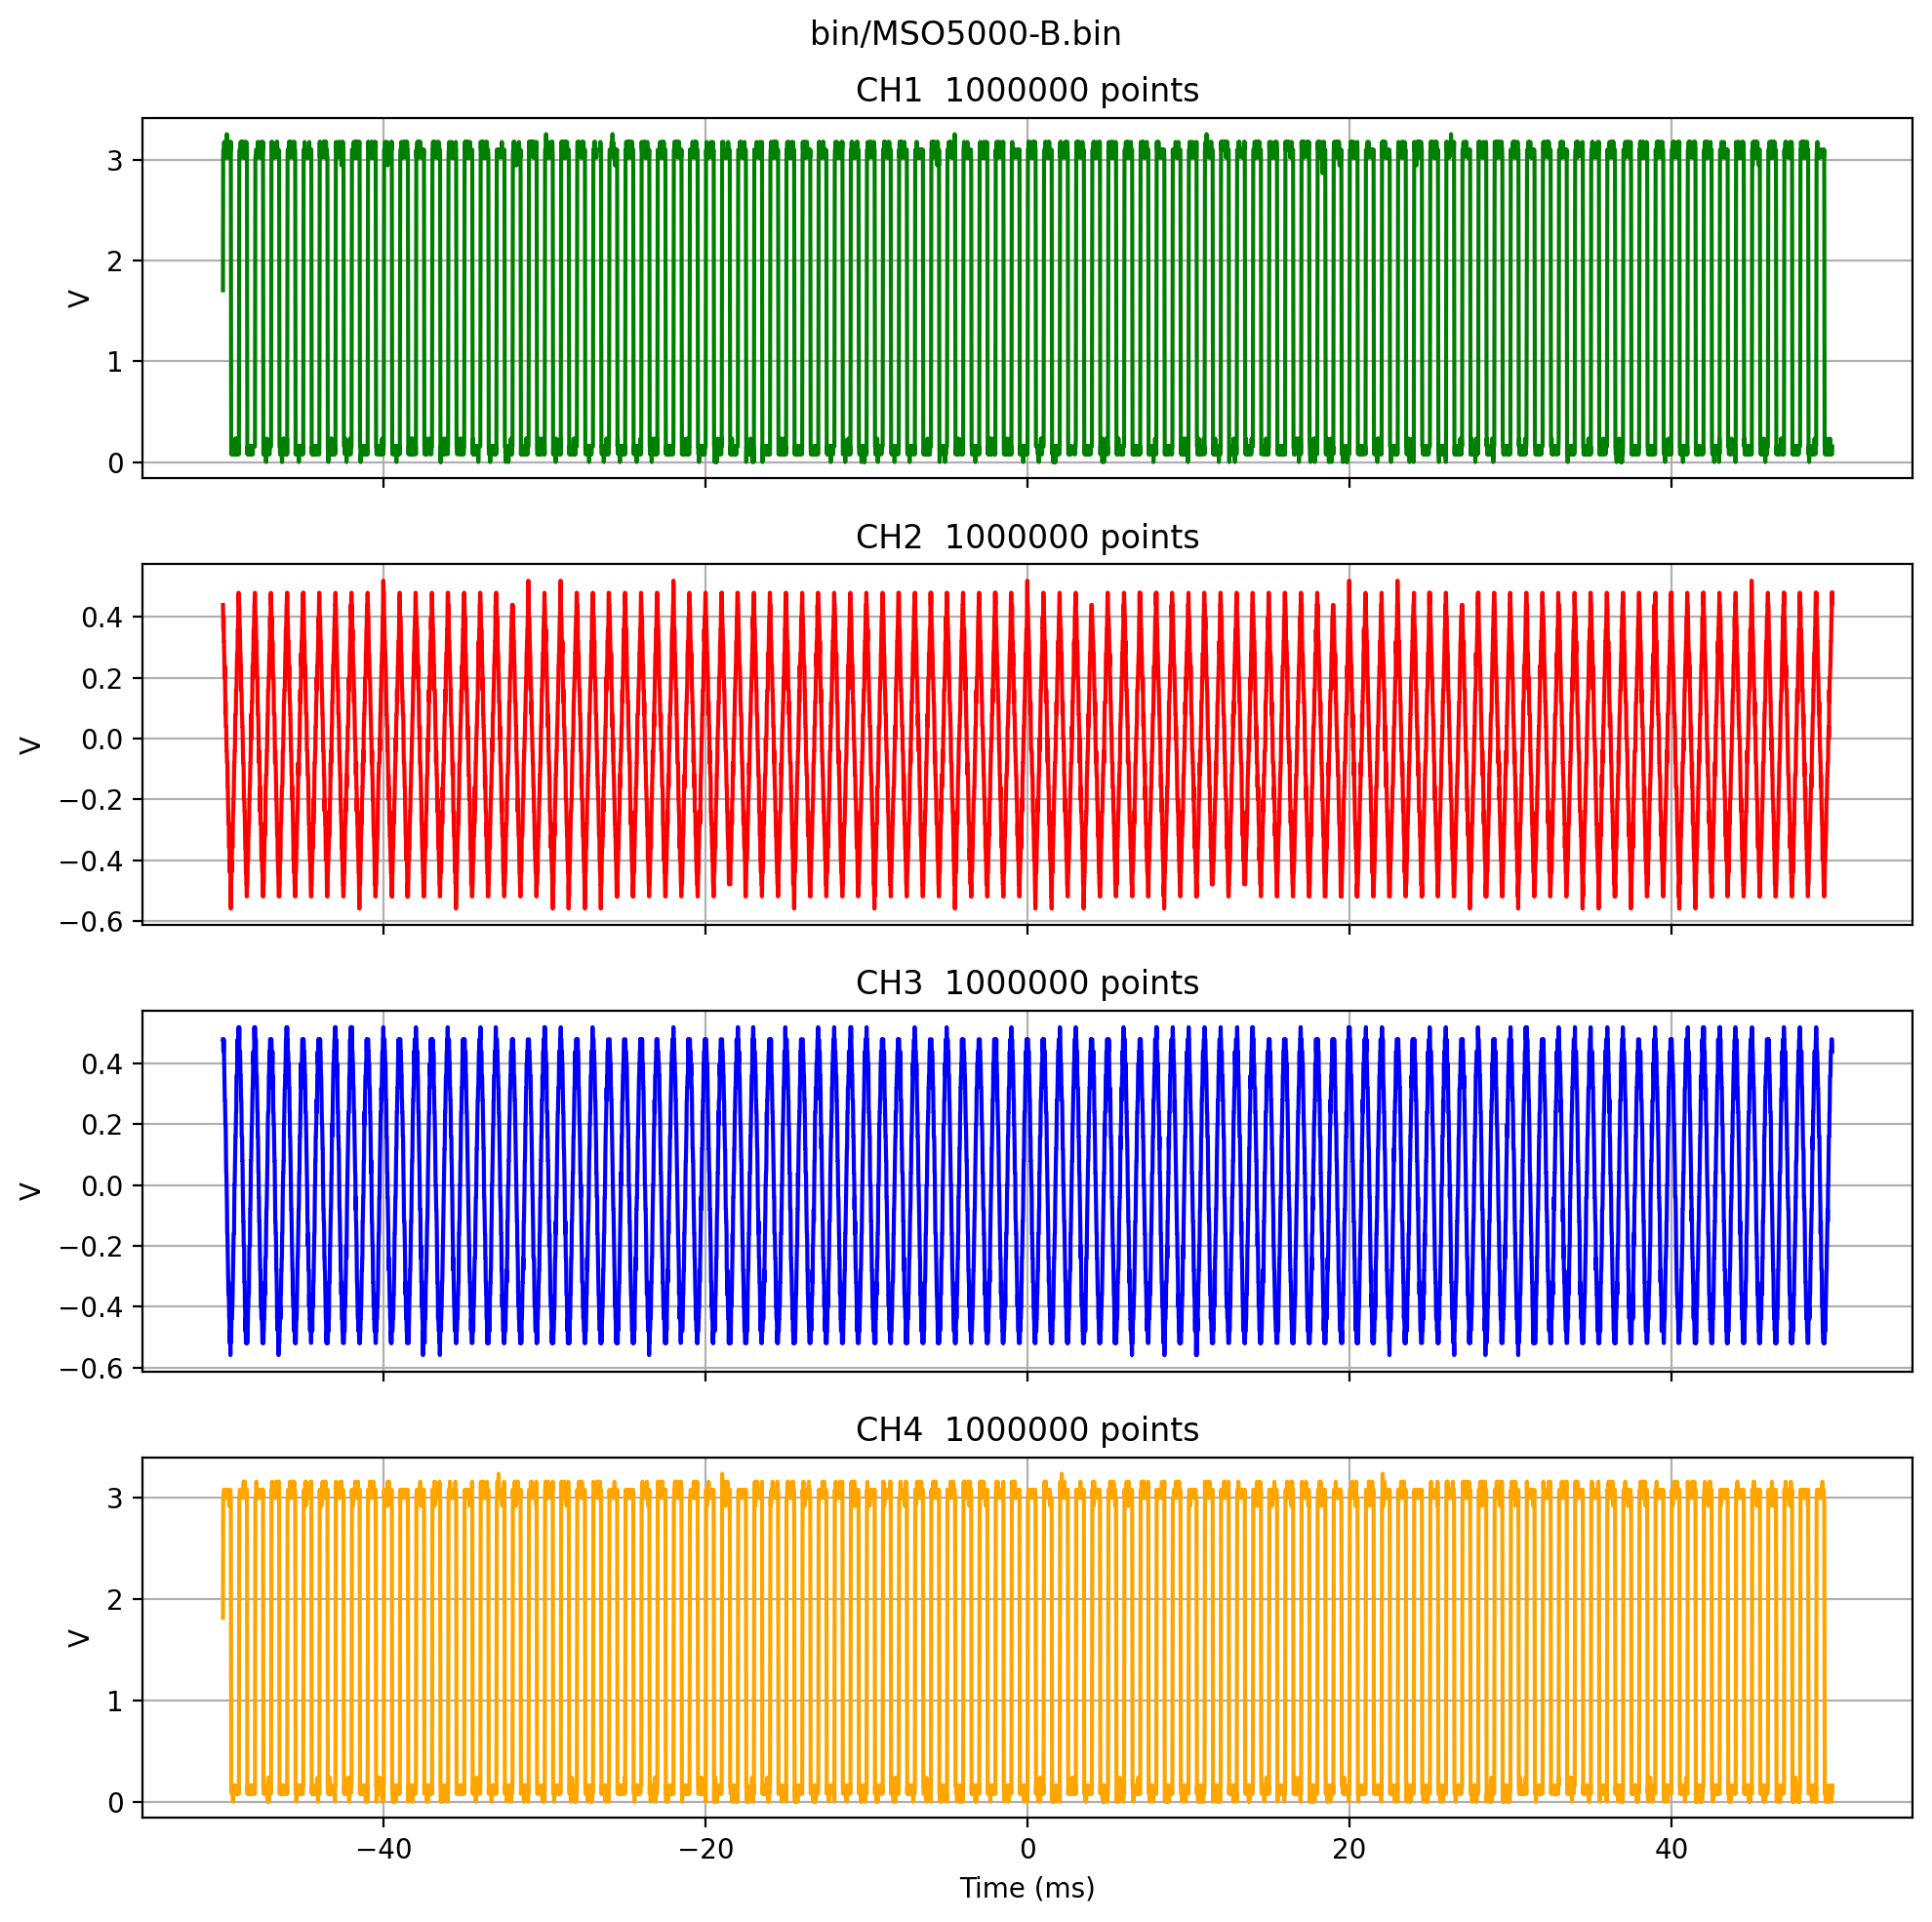

In [6]:
plot_analog_channels(w, title=filename, max_points=8000)

## MSO5074-C - Logic-only RG01 capture

This standard MSO5074 file is handled by the same RG01 / MSO5000 parser, but it exposes digital traces through `logic_channels` instead of `channels`.

In [7]:
filename = 'bin/MSO5074-C.bin'
w = Wfm.from_url(sample_url(filename), '5')
print(w.describe())

    General:
        File Model   = MSO5074
        User Model   = 5
        Parser Model = bin5000
        Firmware     = 01
        Filename     = MSO5074-C.bin
        Channels     = []

    Logic:
        Mapping      = LA D7-D0
        Points       =   500000
        Delta        = 1000.000 ps/point
        Traces       = [D0, D1, D2, D3, D4, D5, D6, D7]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/MSO5074-C.bin'


### Count activity on each decoded logic trace

In [8]:
activity = {name: int(np.count_nonzero(np.diff(trace))) for name, trace in w.logic_channels.items()}
activity

{'D0': 80,
 'D1': 62,
 'D2': 50000,
 'D3': 2,
 'D4': 36,
 'D5': 179,
 'D6': 0,
 'D7': 0}

### Plot the first few active digital traces

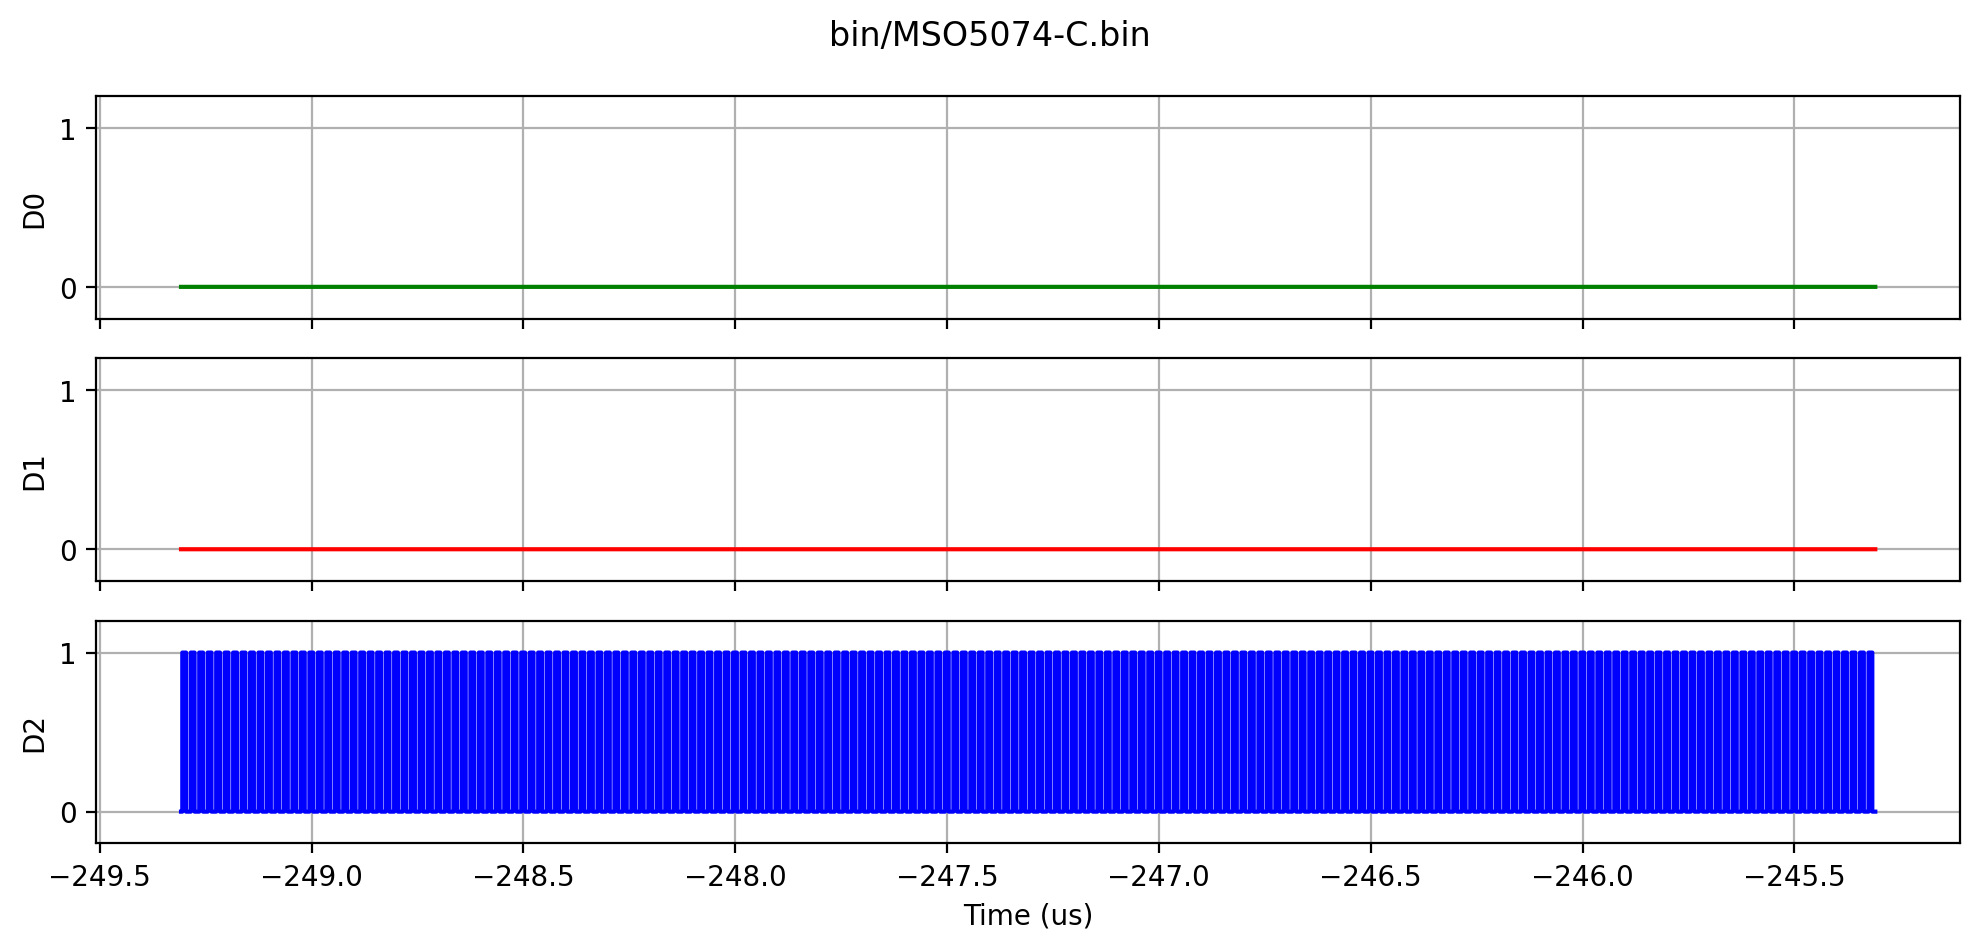

In [9]:
active = [name for name, count in activity.items() if count]
plot_logic_window(w, names=active[:3], stop=4000, title=filename)